<a href="https://colab.research.google.com/github/mateoveega/MCMC-MonteCarlo-TFG/blob/main/CH_1/REJECTION_cauchy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [37]:
# Algoritmo de muestreo por rechazo

def rejection(log_target_pdf, log_envelope_pdf, num_samples, log_k, a, b, c, d):
    accepted_samples = []
    rejected_samples = []

    for i in range(num_samples):
        # Generamos un candidato según el método de la transformada inversa
        x_proposal = inverse_envelope_pdf(np.random.rand(), c, d)

        if x_proposal > 0:
            u = rng.random() # entre 0 y 1

            # Calculamos la condición en el espacio logarítmico
            log_p_tilde = log_target_pdf(x_proposal, a, b)
            log_q = log_envelope_pdf(x_proposal, c, d)

            if np.log(u) <= log_p_tilde - (log_k + log_q):
                accepted_samples.append(x_proposal)
            else:
                rejected_samples.append(x_proposal)
        else:
            rejected_samples.append(x_proposal)

    return np.array(accepted_samples), np.array(rejected_samples)


In [38]:
# Definimos la distribución objetivo
def target_pdf(x, a, b):
    return x ** (a - 1) * np.exp(- x * b)

# Definimos la distribución de propuesta
def envelope_pdf(x, c, d):
    return 1 / (1 + ((x - c) / d) ** 2)

# Definimos el logaritmo de la distribución objetivo
def log_target_pdf(x, a, b):
    return (a - 1) * np.log(x) - (x * b)

# Definimos el logaritmo de la distribución propuesta
def log_envelope_pdf(x, c, d):
    return -np.log(1 + ((x - c) / d) ** 2)

# Inversa de la propuesta (para obtener muestras)
def inverse_envelope_pdf(x, c, d):
    return c + d * np.tan(np.pi * (x - 1 / 2))

In [39]:
# Definimos los parametros de la distribución
a = 5
b = 2

# Optimizamos los parámetros de dispersión y escala
c = (a - 1) / b
d = (np.sqrt(2 * a - 1)) / b


In [40]:
# Determinamos la constante k

x_range = np.linspace(0.001, 10, 1000) # Ajustado para que x sea positivo

# Calculamos la diferencia de los logaritmos
log_ratio = log_target_pdf(x_range, a, b) - log_envelope_pdf(x_range, c, d)
log_k = np.max(log_ratio)

k = np.exp(log_k)

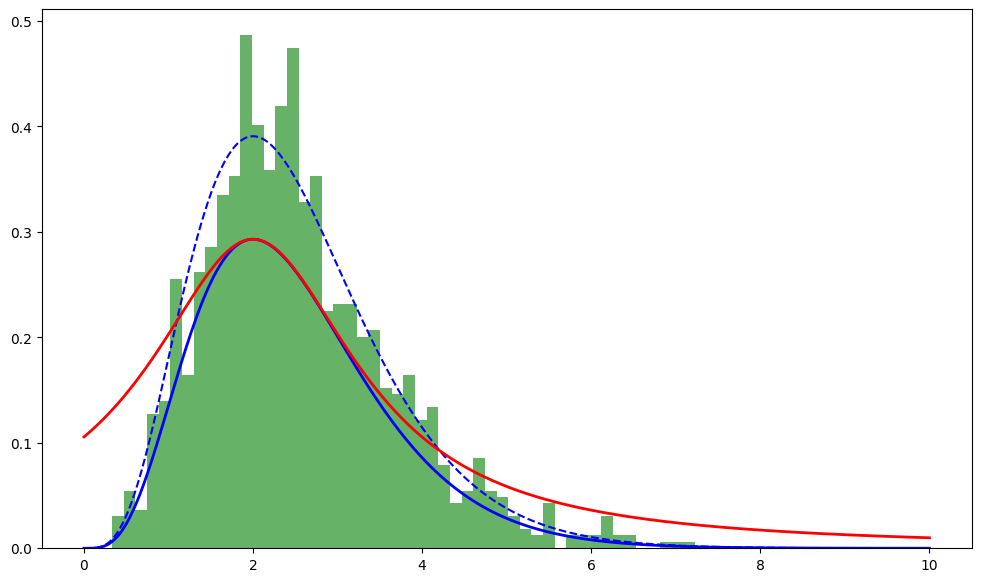

In [41]:
from scipy.special import gamma as gamma_func

# Establecemos una semilla para la replicabilidad de la imagen
rng = np.random.default_rng(1)

# Generamos las muestras a partir de nuestra función
accepted_samples, rejected_samples = rejection(log_target_pdf, log_envelope_pdf, 10000, k, a, b, c, d)

# Visualizamos los resultados
plt.figure(figsize=(12, 7))
x_plot = np.linspace(0.001, 10, 500) # Ajustado para que x sea positivo

# Graficamos la distribución objetivo sin normalizar
plt.plot(x_plot, target_pdf(x_plot, a, b), color='blue', linewidth=2)

# Graficamos la distribución objetivo normalizada
zp = gamma_func(a) / (b**a)  # Constante de normalización

plt.plot(x_plot, np.exp(log_target_pdf(x_plot, a, b)) / zp, color='blue', linestyle='--')

# Graficamos la envolvente escalada (k * envolvente_pdf)
plt.plot(x_plot, k * envelope_pdf(x_plot, c, d), color='red', linewidth=2)

# Histograma de las muestras aceptadas
plt.hist(accepted_samples, bins=50, density=True, alpha=0.6, color='green')
plt.ylim(bottom=0)

# Guardamos la imagen
plt.savefig("RECHAZO_cauchy.pdf")

plt.show()


In [42]:
from google.colab import files
files.download("RECHAZO_cauchy.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>